### Imports

In [1]:
!pip install grad-cam --quiet

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import timm
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
from torchvision import transforms

from PIL import Image
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score, confusion_matrix, classification_report

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import warnings
warnings.filterwarnings("ignore")

### Train/Val Split

Created the output of the v4 run as a dataset and added it as input here
The Dataset now contains
- HAM10000_metadata_split_80_20.csv
- best_model_oversample_aug_dropout.pth
- train_cache.pt
- val_cache.pt

In [3]:
split = pd.read_csv("/kaggle/input/datasets/kaushalvaid/ham10k-model-and-cached-tensors/HAM10000_metadata_split_80_20.csv")

train_df = split[split['split'] == 'train']
val_df = split[split['split'] == 'val']

print(train_df.shape)
print(val_df.shape)

(8033, 8)
(1982, 8)


In [4]:
label_map = {label : idx for idx, label in enumerate(sorted(split['dx'].unique()))}

class_names = sorted(label_map, key=label_map.get)

print(class_names)
print(label_map)

['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


### Dataset / DataLoader

In [5]:
class CachedHAMDataset(Dataset):
    def __init__(self, cache_path, df, label_map, augment=None):
        self.images = torch.load(cache_path)
        self.labels = [label_map[l] for l in df['dx']]
        self.augment = augment

        # augmentation
        self.train_aug = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(20),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1)
        ])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]

        if self.augment:
            img = self.train_aug(img)

        return img, self.labels[idx]


# ---

train_cache_path = "/kaggle/input/datasets/kaushalvaid/ham10k-model-and-cached-tensors/train_cache.pt"
val_cache_path = "/kaggle/input/datasets/kaushalvaid/ham10k-model-and-cached-tensors/val_cache.pt"

train_ds = CachedHAMDataset(train_cache_path, train_df, label_map, augment=True)
val_ds = CachedHAMDataset(val_cache_path, val_df, label_map, augment=False)

class_counts = train_df['dx'].value_counts().reindex(class_names)
class_weights = 1.0 / class_counts
sample_weights = train_df['dx'].map(class_weights).values

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    sampler=sampler,
    drop_last=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

### TTA

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

model = timm.create_model(
    "efficientnet_b4",
    pretrained=True,
    num_classes=7,
    drop_rate=0.3, # dropout before final classifier
    drop_path_rate=0.2 # stochastic depth — drops entire residual blocks during training
)
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [16]:
checkpoint = torch.load("/kaggle/input/datasets/kaushalvaid/ham10k-model-and-cached-tensors/best_model_oversample_aug_dropout.pth")
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

def tta_predict_batch(model, images):
    """images: already normalized [B,3,380,380] tensor on device"""
    transforms_list = [
        lambda x: x,
        lambda x: torch.flip(x, dims=[-1]),
        lambda x: torch.flip(x, dims=[-2]),
        lambda x: torch.rot90(x, k=1, dims=[-2, -1]),
        lambda x: torch.rot90(x, k=3, dims=[-2, -1]),
    ]
    probs_sum = None
    with torch.no_grad():
        for t in transforms_list:
            aug = t(images)
            with autocast():
                out = model(aug)
            probs = torch.softmax(out, dim=1)
            probs_sum = probs if probs_sum is None else probs_sum + probs
    return probs_sum / len(transforms_list)

all_preds_tta = []
all_labels_tta = []

for images, labels in val_loader:
    images = images.to(device, non_blocking=True)
    labels = labels.to(device)
    images = (images - MEAN) / STD

    avg_probs = tta_predict_batch(model, images)
    preds = torch.argmax(avg_probs, dim=1)

    all_preds_tta.extend(preds.cpu().numpy())
    all_labels_tta.extend(labels.cpu().numpy())

print("TTA Macro F1:", f1_score(all_labels_tta, all_preds_tta, average='macro'))
print(classification_report(all_labels_tta, all_preds_tta, target_names=class_names, digits=3))

TTA Macro F1: 0.7624860066382613
              precision    recall  f1-score   support

       akiec      0.800     0.611     0.693        72
         bcc      0.750     0.794     0.771       102
         bkl      0.819     0.798     0.808       193
          df      0.857     0.444     0.585        27
         mel      0.631     0.704     0.665       223
          nv      0.934     0.931     0.933      1339
        vasc      0.788     1.000     0.881        26

    accuracy                          0.868      1982
   macro avg      0.797     0.755     0.762      1982
weighted avg      0.871     0.868     0.868      1982



### Grad-CAM

What my CNN is actually seeing

In [42]:
# get plain predictions with index tracking
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:  # this loader must NOT shuffle, so order matches val_ds
        images = images.to(device, non_blocking=True)
        images = (images - MEAN) / STD
        labels = labels.to(device)
        with autocast():
            outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# sanity check — val_loader must have shuffle=False for this indexing to be valid
assert len(all_preds) == len(val_ds)

In [28]:
for stage_idx in [3, 4, 5, 6]:
    activation = {}
    def hook(module, input, output):
        activation['out'] = output.detach()
    handle = model.blocks[stage_idx].register_forward_hook(hook)
    with torch.no_grad():
        _ = model((val_ds.images[1147].unsqueeze(0).to(device) - MEAN) / STD)
    handle.remove()
    print(f"blocks[{stage_idx}] output shape:", activation['out'].shape)

blocks[3] output shape: torch.Size([1, 112, 24, 24])
blocks[4] output shape: torch.Size([1, 160, 24, 24])
blocks[5] output shape: torch.Size([1, 272, 12, 12])
blocks[6] output shape: torch.Size([1, 448, 12, 12])


In [56]:
target_layers = [model.blocks[3]]
cam = GradCAM(model=model, target_layers=target_layers)

# from pytorch_grad_cam import GradCAMPlusPlus
# cam = GradCAMPlusPlus(model=model, target_layers=[model.blocks[3]])

Selecting Indices

In [47]:
label_to_idx = {name: i for i, name in enumerate(class_names)}

# 1. correct high-confidence nv (sanity check)
nv_correct = np.where((all_labels == label_to_idx['nv']) & (all_preds == label_to_idx['nv']))[0]
nv_picks = np.random.choice(nv_correct, 2, replace=False)

# 2. correct minority-class predictions
minority_correct_picks = []
for cls in ['akiec', 'bcc', 'vasc']:
    correct = np.where((all_labels == label_to_idx[cls]) & (all_preds == label_to_idx[cls]))[0]
    if len(correct) > 0:
        minority_correct_picks.append(np.random.choice(correct, 1)[0])

# 3. mel -> nv misclassifications (your largest error block, 66 cases per your confusion matrix)
mel_to_nv = np.where((all_labels == label_to_idx['mel']) & (all_preds == label_to_idx['nv']))[0]
mel_nv_picks = np.random.choice(mel_to_nv, 2, replace=False)

# 4. df misclassifications (df -> akiec/bcc/mel, your weakest class)
df_wrong = np.where((all_labels == label_to_idx['df']) & (all_preds != label_to_idx['df']))[0]
df_picks = np.random.choice(df_wrong, min(2, len(df_wrong)), replace=False)

selected_indices = list(nv_picks) + minority_correct_picks + list(mel_nv_picks) + list(df_picks)
print(f"Selected {len(selected_indices)} indices: {selected_indices}")
for idx in selected_indices:
    print(f"idx={idx}, true={class_names[all_labels[idx]]}, pred={class_names[all_preds[idx]]}")

Selected 9 indices: [np.int64(865), np.int64(1777), np.int64(1933), np.int64(517), np.int64(447), np.int64(306), np.int64(431), np.int64(213), np.int64(195)]
idx=865, true=nv, pred=nv
idx=1777, true=nv, pred=nv
idx=1933, true=akiec, pred=akiec
idx=517, true=bcc, pred=bcc
idx=447, true=vasc, pred=vasc
idx=306, true=mel, pred=nv
idx=431, true=mel, pred=nv
idx=213, true=df, pred=nv
idx=195, true=df, pred=bkl


In [48]:
def generate_gradcam(idx, dataset, true_label_idx, pred_label_idx=None):
    img_tensor = dataset.images[idx].unsqueeze(0).to(device)
    img_norm = (img_tensor - MEAN) / STD

    with torch.no_grad():
        with autocast():
            out = model(img_norm)
        probs = torch.softmax(out, dim=1)
        pred_label_idx = out.argmax(dim=1).item()
        confidence = probs[0, pred_label_idx].item()

    targets = [ClassifierOutputTarget(pred_label_idx)]
    grayscale_cam = cam(input_tensor=img_norm, targets=targets)[0]

    # print(f"idx={idx} conf={confidence:.3f} cam_min={grayscale_cam.min():.3f} cam_max={grayscale_cam.max():.3f} cam_mean={grayscale_cam.mean():.3f}")

    rgb_img = img_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    rgb_img = np.clip(rgb_img, 0, 1)
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True, image_weight=0.3)
    return visualization, pred_label_idx

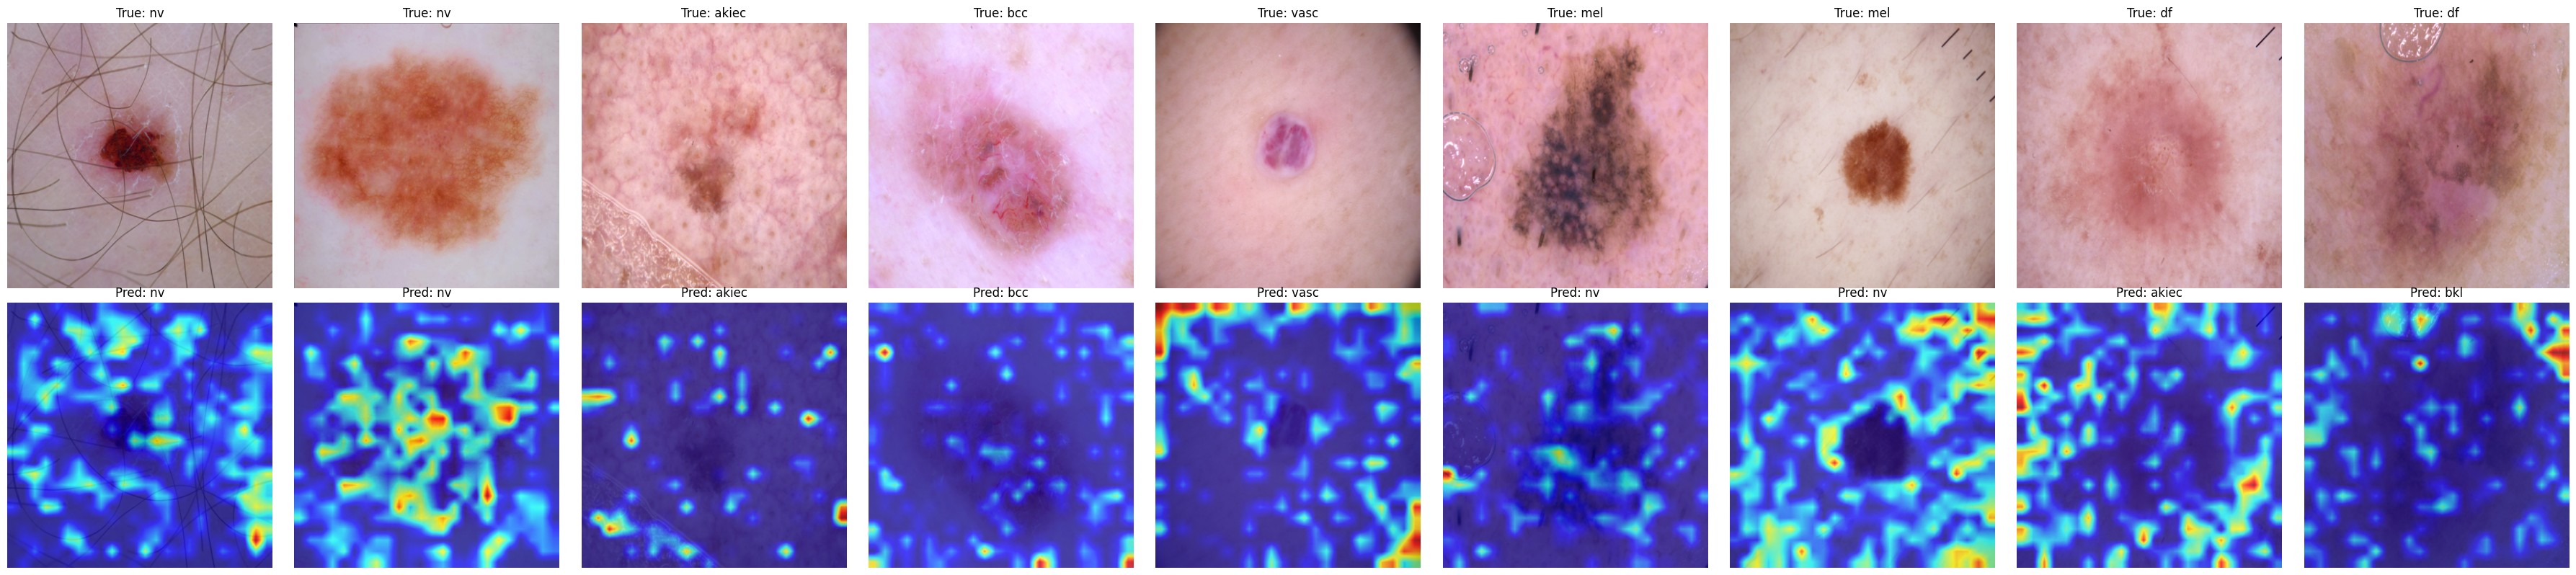

In [57]:
selected_indices = [1408, 1743, 1970, 494, 448, 375, 407, 203, 198]

fig, axes = plt.subplots(2, len(selected_indices), figsize=(4*len(selected_indices), 8))
for i, idx in enumerate(selected_indices):
    true_label = val_ds.labels[idx]
    orig_img = val_ds.images[idx].permute(1, 2, 0).numpy()
    cam_img, pred_label = generate_gradcam(idx, val_ds, true_label)

    axes[0, i].imshow(orig_img)
    axes[0, i].set_title(f"True: {class_names[true_label]}")
    axes[0, i].axis('off')

    axes[1, i].imshow(cam_img)
    axes[1, i].set_title(f"Pred: {class_names[pred_label]}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/gradcam_results.png', dpi=150)
plt.show()